C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1399418112.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1399418112.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1399418112.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1399418112.py:21: FutureWarning: YF.download() has changed argument auto_ad

                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns           1.000000           0.813035
BUYANDHOLDReturns         0.813035           1.000000
                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns           1.000000           0.860698
BUYANDHOLDReturns         0.860698           1.000000
                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns           1.000000           0.873522
BUYANDHOLDReturns         0.873522           1.000000
                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns           1.000000           0.819645
BUYANDHOLDReturns         0.819645           1.000000
                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns            1.00000            0.78002
BUYANDHOLDReturns          0.78002            1.00000
                   StrategyReturns  BUYANDHOLDReturns
StrategyReturns             1.0000             0.8288
BUYANDHOLDReturns           0.8288             1.0000
                   StrategyR

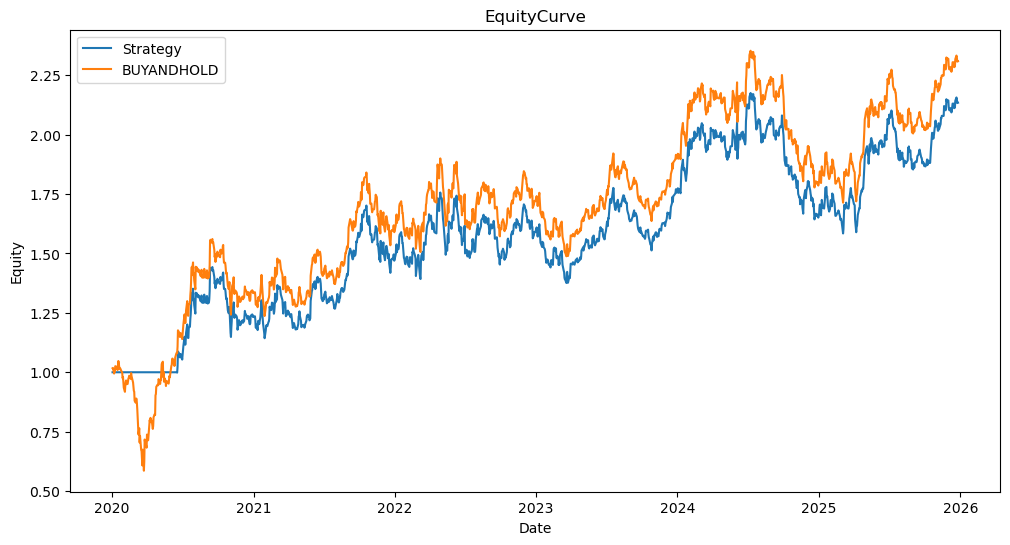

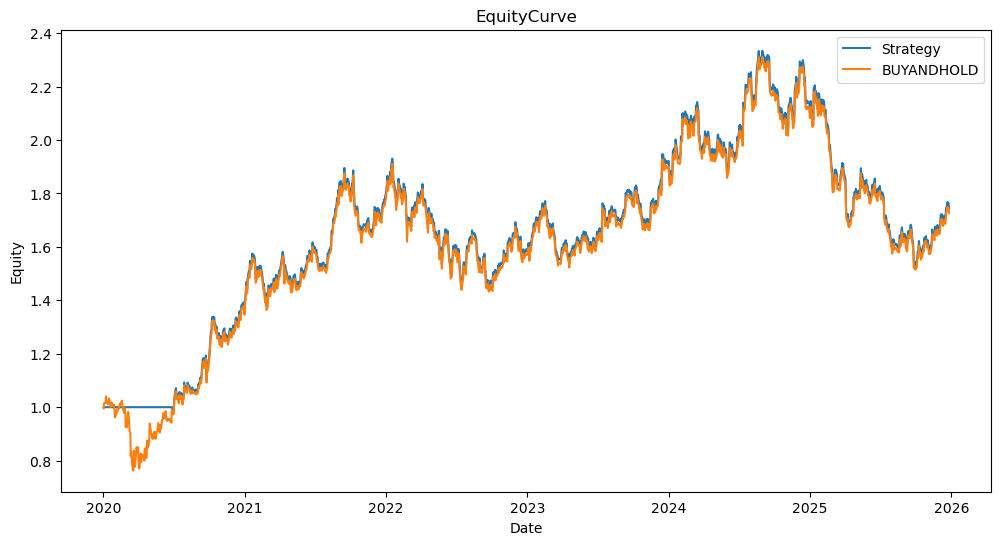

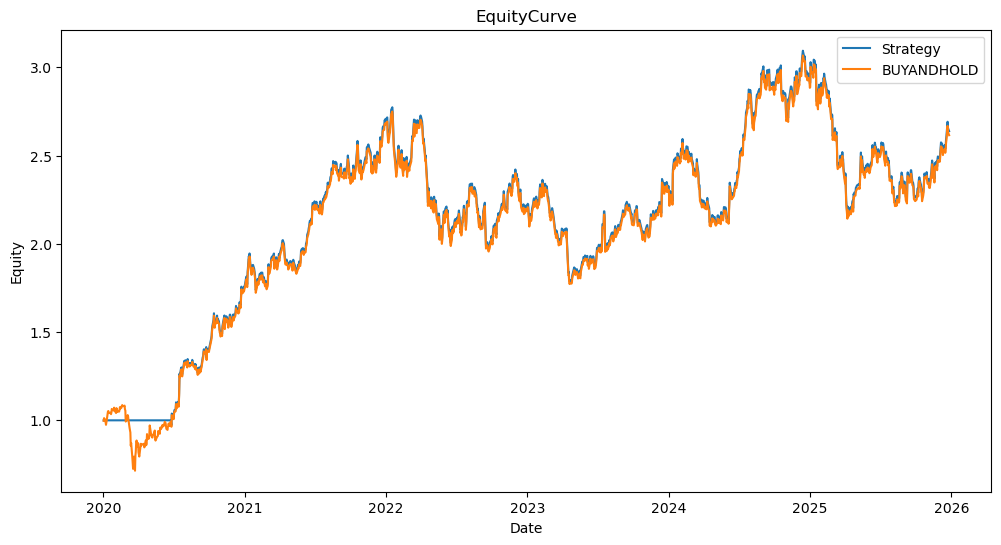

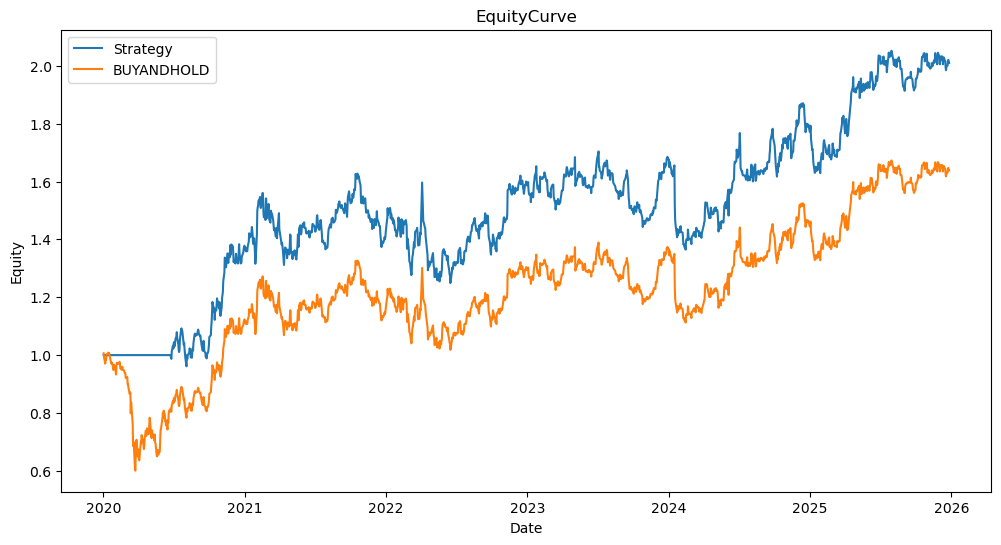

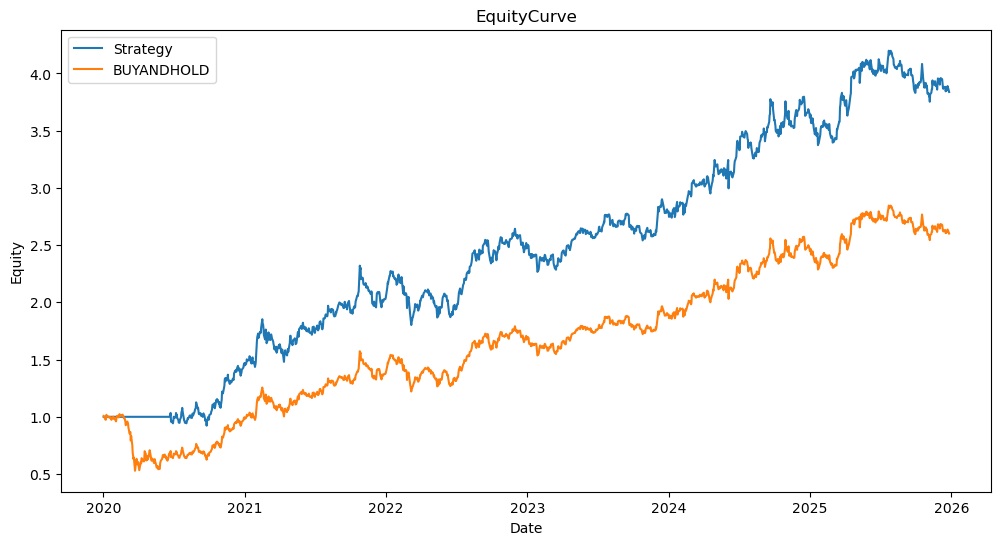

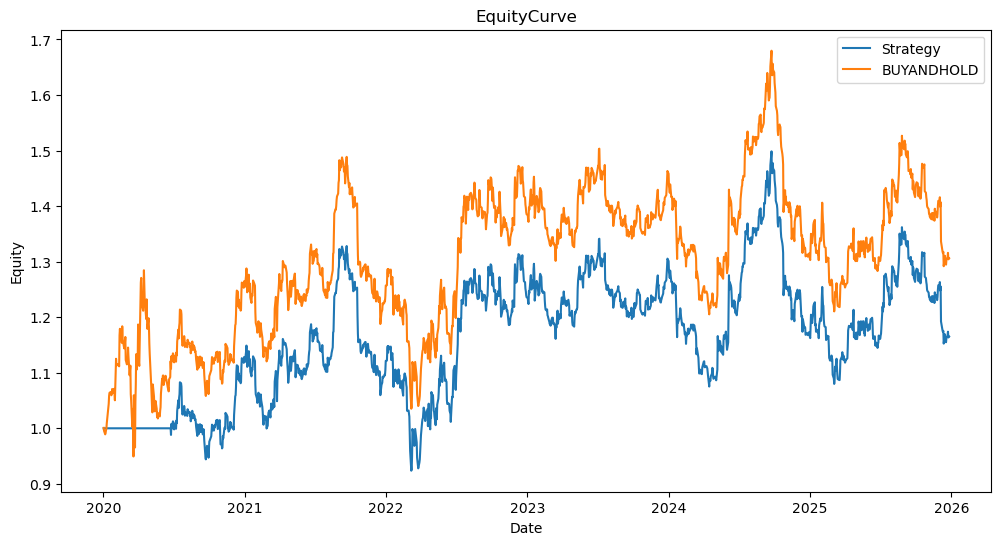

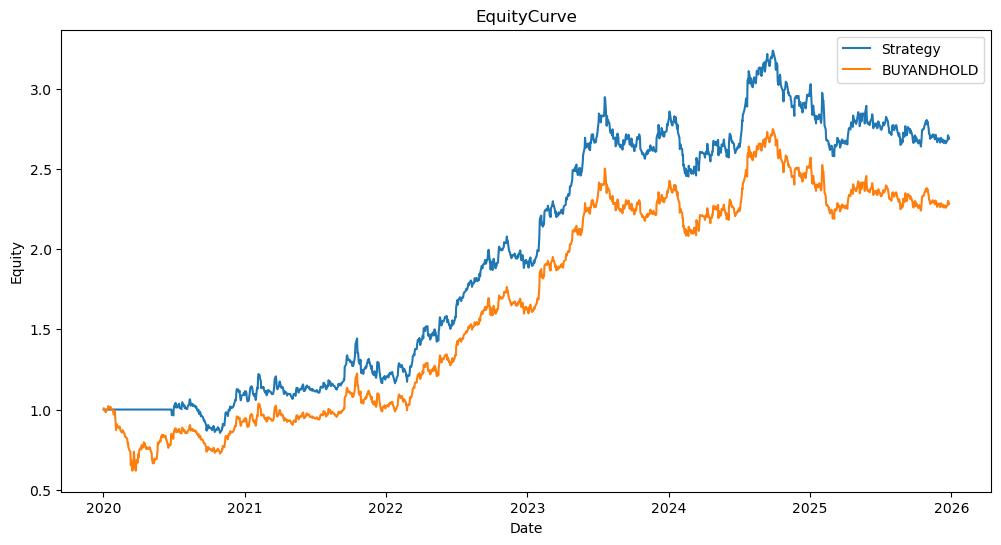

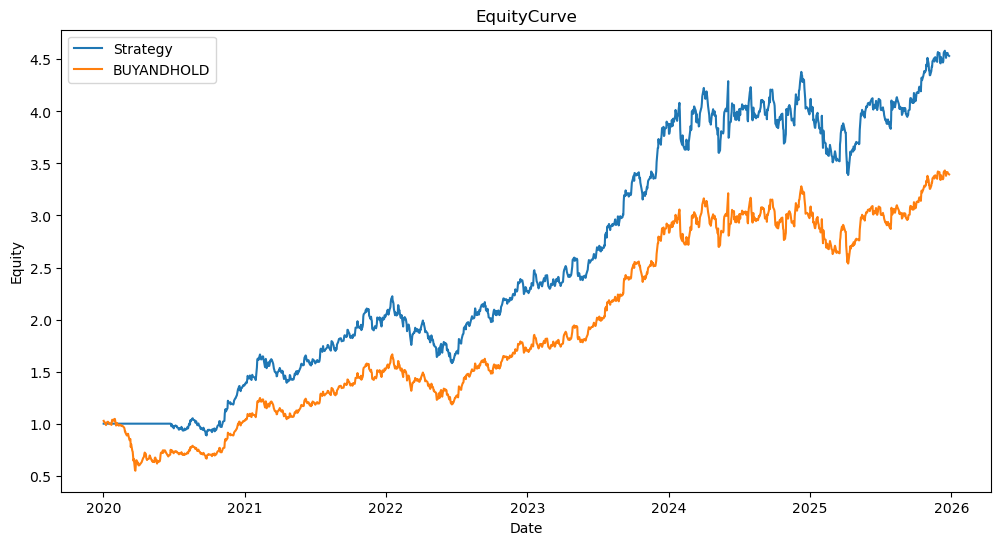

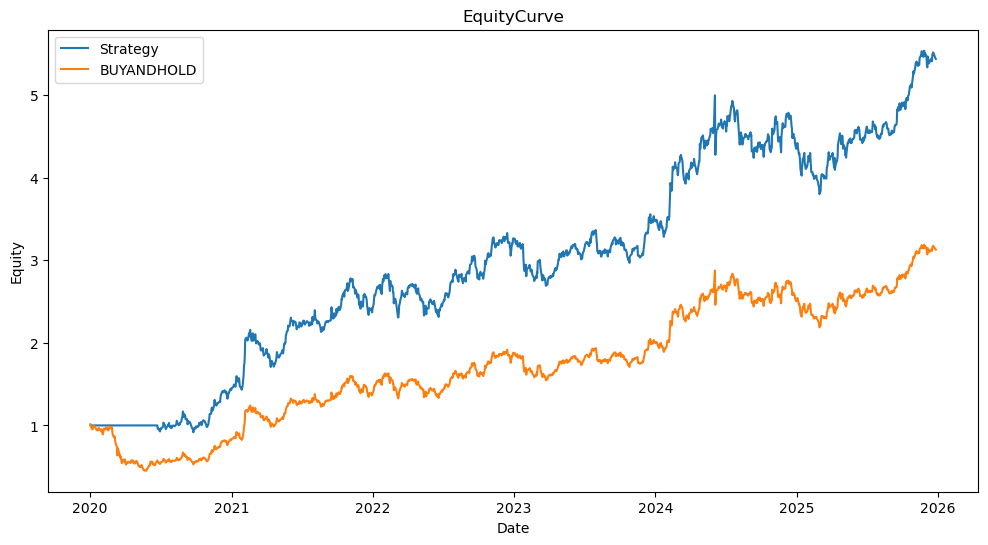

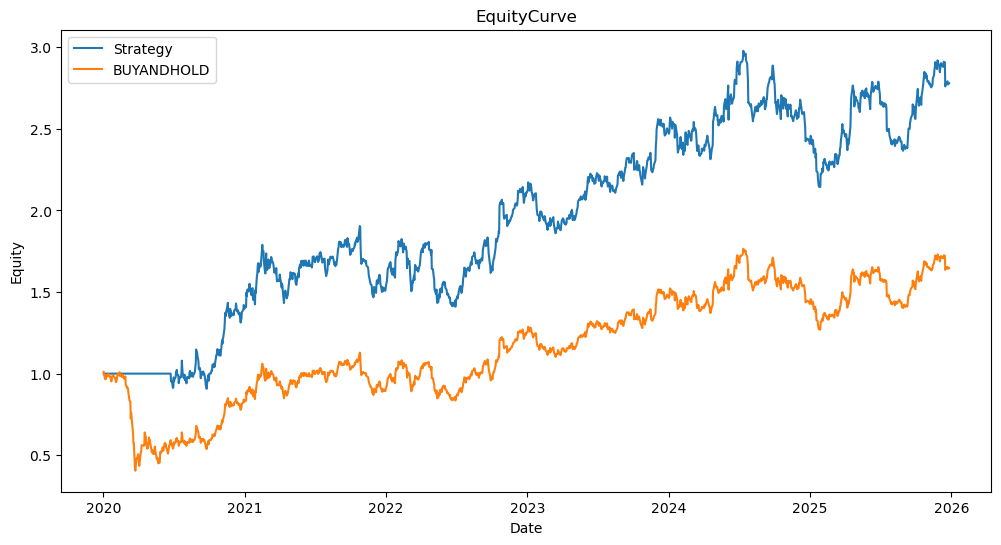

In [82]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


tickers=[
    "RELIANCE.NS",   # Reliance Industries
    "TCS.NS",        # Tata Consultancy Services
    "INFY.NS",       # Infosys
    "HDFCBANK.NS",   # HDFC Bank
    "ICICIBANK.NS",  # ICICI Bank
    "HINDUNILVR.NS", # Hindustan Unilever
    "ITC.NS",        # ITC
    "LT.NS",         # Larsen & Toubro
    "SBIN.NS",       # State Bank of India
    "AXISBANK.NS"    # Axis Bank
]
data={}
for ticker in tickers:
    df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
    data[ticker]=df

DailyCapital=1,000,000

def run_strategy(ticker):
    df=data[ticker]
    df["LowInWindow"]=df["Close"].rolling(window=10).min().shift(1)
    df["HighInWindow"]=df["Close"].rolling(window=10).max().shift(1)
    df["PriceIncrease"]=df["Close"].pct_change()
    df["Signal"]=0
    df["ClosePriceVolatility"]=df["PriceIncrease"].rolling(window=10).std().shift(1)
    df["VolFilter"]=df["ClosePriceVolatility"]<df["ClosePriceVolatility"].rolling(100).mean().shift(1)
    df.loc[((df["Close"]>df["HighInWindow"])&(df["VolFilter"]==1)), "Signal"]=1
    df.loc[((df["Close"]<df["LowInWindow"])), "Signal"]=0
    df["Position"]=df["Signal"].replace(0,np.nan).ffill().fillna(0)
    df["StrategyReturns"]=df["PriceIncrease"]*df["Position"].shift(1)
    df["BUYANDHOLDReturns"]=df["PriceIncrease"]
    df_clean=df.dropna()
    MeanReturnStrategy=df_clean["StrategyReturns"].mean()
    VolatilityStrategy=df_clean["StrategyReturns"].std()
    MeanReturnBUYANDHOLD=df_clean["BUYANDHOLDReturns"].mean()
    VolatilityBUYANDHOLD=df_clean["BUYANDHOLDReturns"].std()
    #print("____________________________________________")
    #print(f"Mean return by strategy is: {MeanReturnStrategy}")
    #print(f"Volatility of returns by strategy 1 is: {VolatilityStrategy}")
    #print(f"Sharpe Ratio: {np.sqrt(252)*MeanReturnStrategy/VolatilityStrategy}")
    #print("____________________________________________")
    #print(f"Mean return by BUYANDHOLD is: {MeanReturnBUYANDHOLD}")
    #print(f"Volatility of returns by BUYANDHOLD is: {VolatilityBUYANDHOLD}")
    #print(f"Sharpe Ratio: {np.sqrt(252)*MeanReturnBUYANDHOLD/VolatilityBUYANDHOLD}")
    #print("____________________________________________")
    #print(df)
    #print("____________________________________________")
    plt.style.use("default")
    df["StrategyEquity"]=(1+df["StrategyReturns"]).cumprod()
    df["BUYANDHOLDEquity"]=(1+df["BUYANDHOLDReturns"]).cumprod()
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df["StrategyEquity"], label="Strategy")
    plt.plot(df.index, df["BUYANDHOLDEquity"], label="BUYANDHOLD")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.title("EquityCurve")
    plt.legend()
    print(df_clean[["StrategyReturns", "BUYANDHOLDReturns"]].corr())
    return

for ticker in tickers:
    run_strategy(ticker)
plt.show()


C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1099737716.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1099737716.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1099737716.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
[*********************100%***********************]  1 of 1 completed
C:\Users\Manav Soni\AppData\Local\Temp\ipykernel_17684\1099737716.py:34: FutureWarning: YF.download() has changed argument auto_ad

{'RELIANCE.NS': 0, 'TCS.NS': 0, 'INFY.NS': 0, 'HDFCBANK.NS': 0, 'ICICIBANK.NS': 0, 'ITC.NS': 0, 'LT.NS': 0, 'SBIN.NS': 0, 'AXISBANK.NS': 0, 'HINDUNILVR.NS': 0, 'ADANIENT.NS': 0, 'TATAMOTORS.NS': 0, 'BAJFINANCE.NS': 0, 'PIDILITIND.NS': 0, 'DLF.NS': 0, 'HAVELLS.NS': 0, 'TRENT.NS': 0, 'TVSMOTOR.NS': 0, 'SUNPHARMA.NS': 0, 'NESTLEIND.NS': 0}
           Ticker  Allocated Capital
0     RELIANCE.NS                  0
1          TCS.NS                  0
2         INFY.NS                  0
3     HDFCBANK.NS                  0
4    ICICIBANK.NS                  0
5          ITC.NS                  0
6           LT.NS                  0
7         SBIN.NS                  0
8     AXISBANK.NS                  0
9   HINDUNILVR.NS                  0
10    ADANIENT.NS                  0
11  TATAMOTORS.NS                  0
12  BAJFINANCE.NS                  0
13  PIDILITIND.NS                  0
14         DLF.NS                  0
15     HAVELLS.NS                  0
16       TRENT.NS               

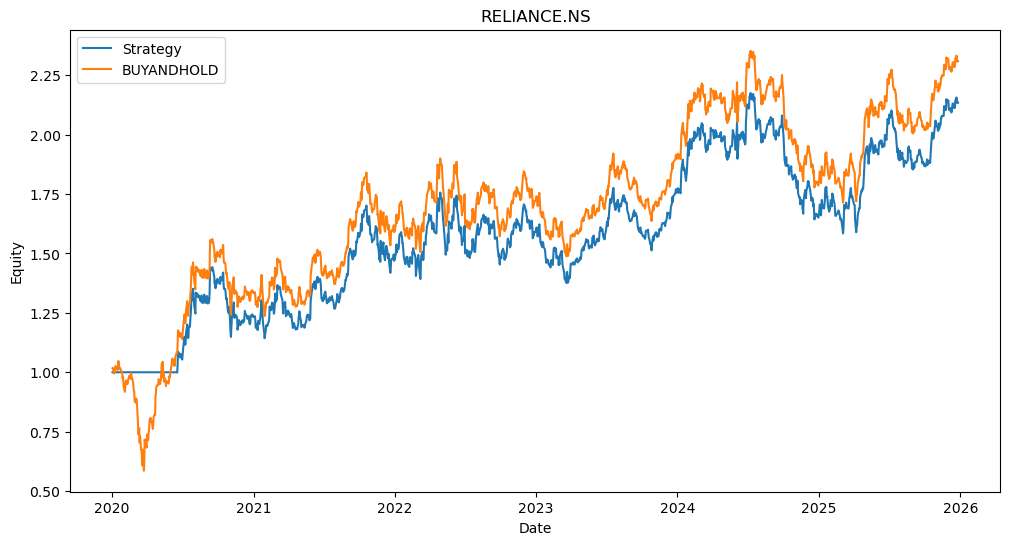

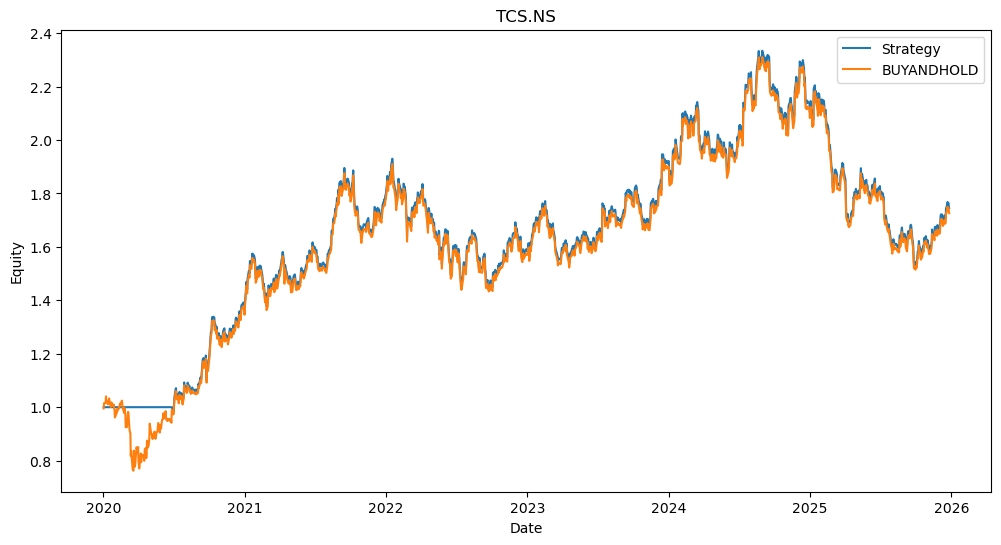

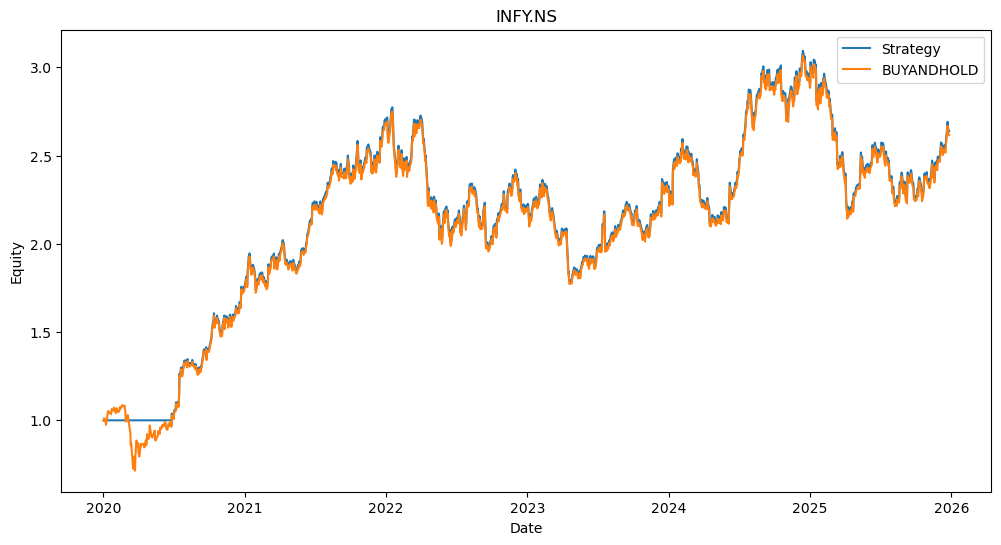

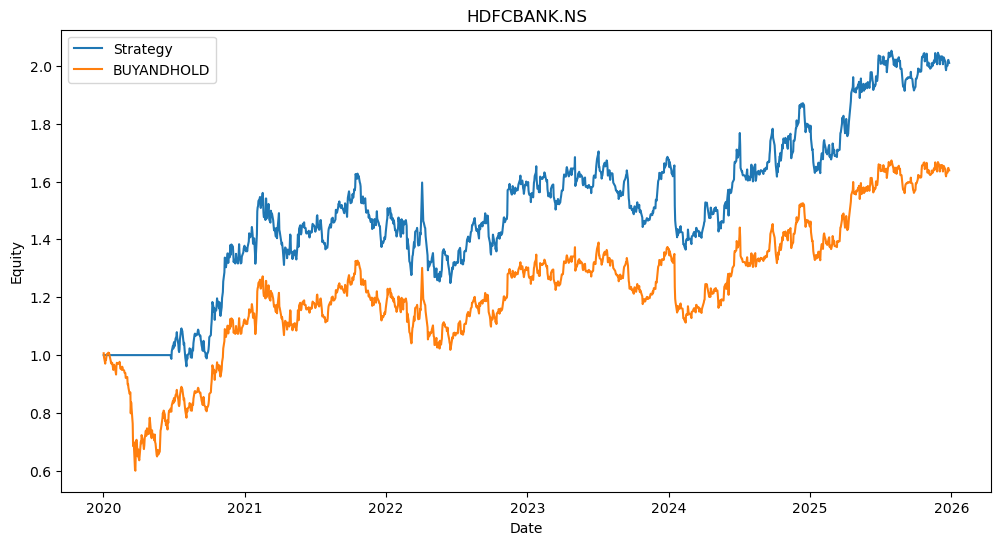

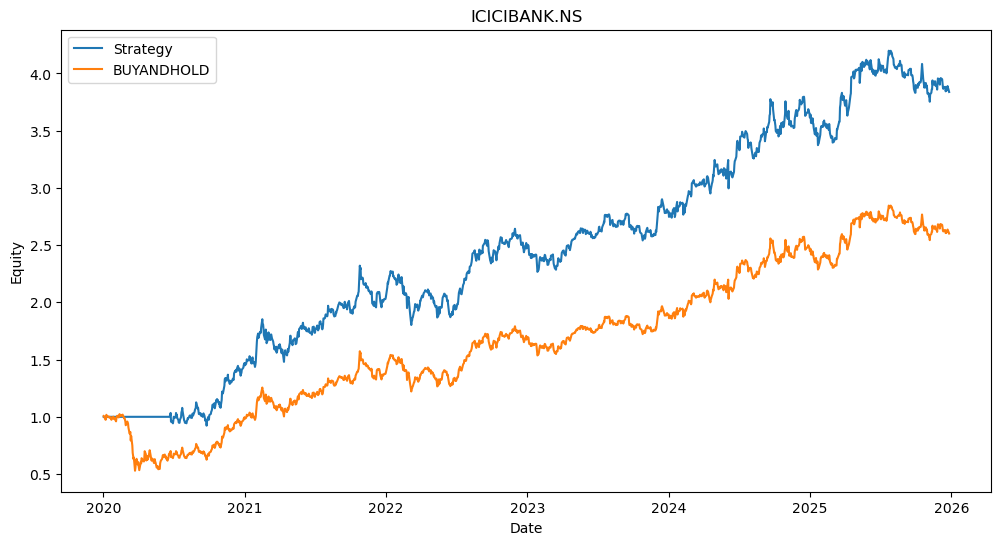

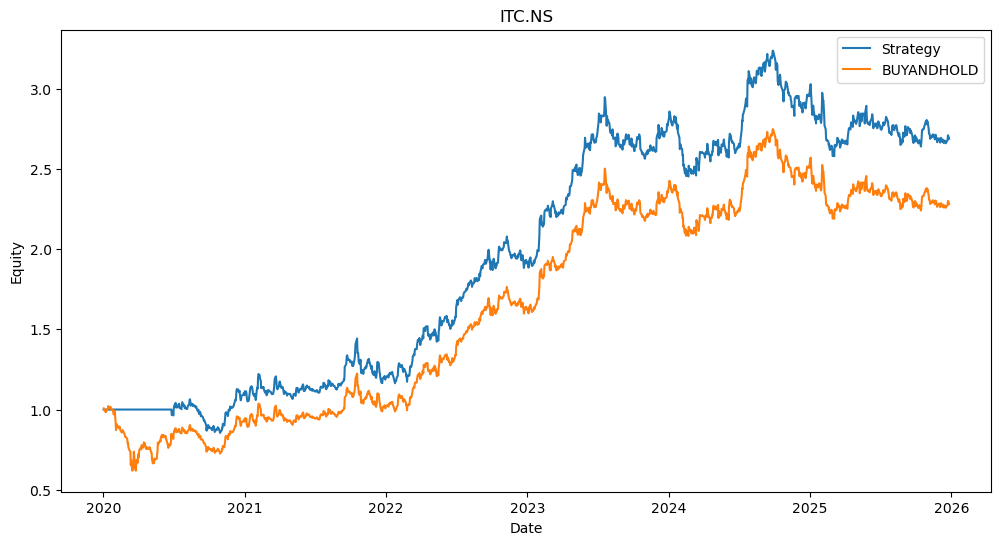

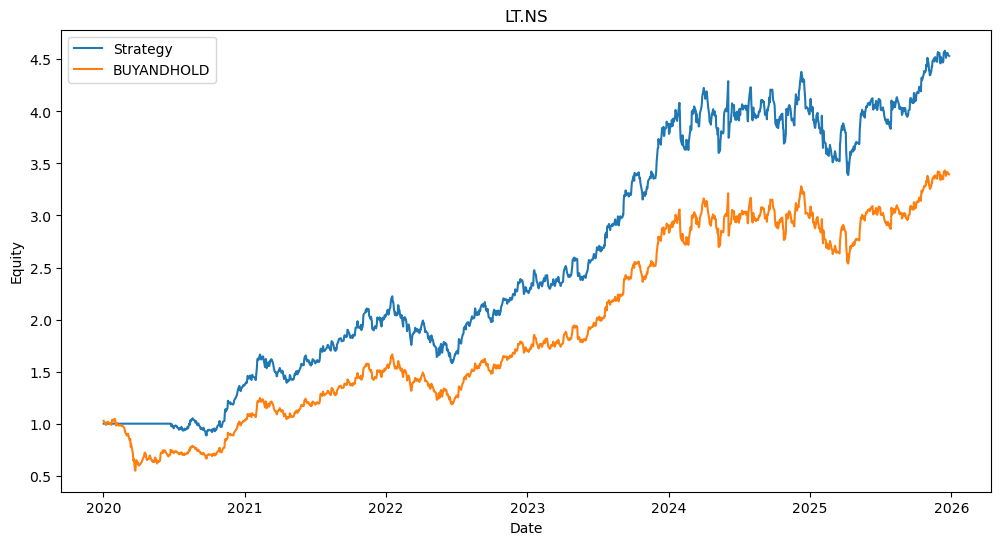

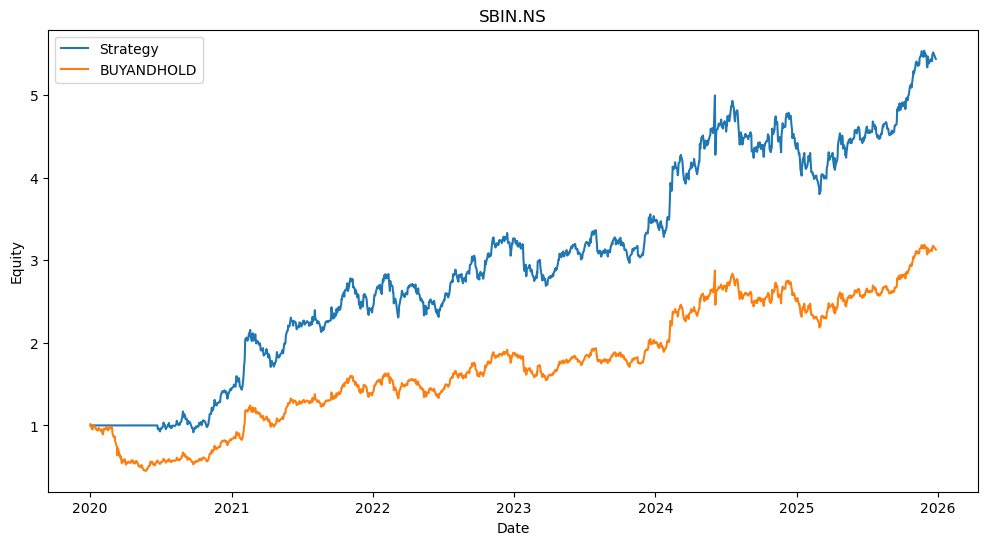

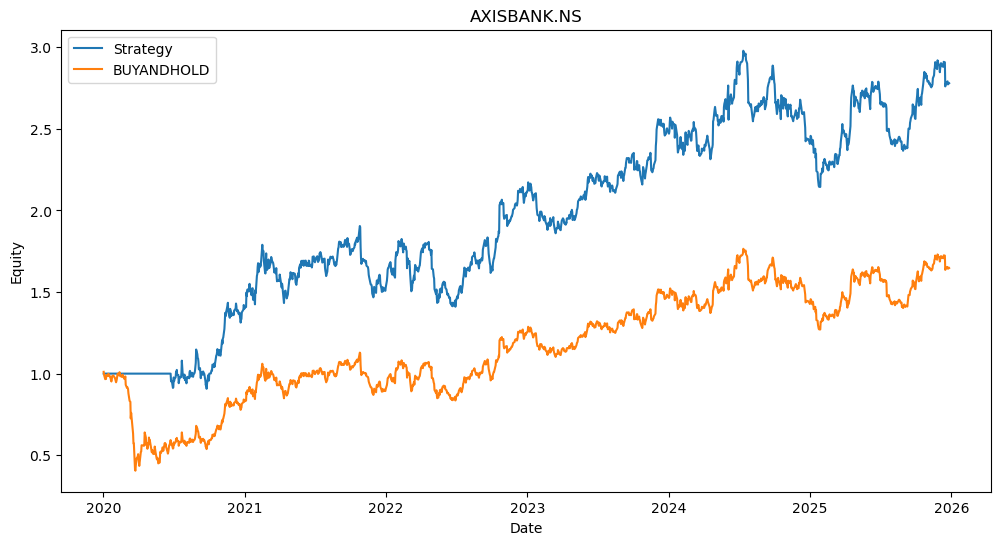

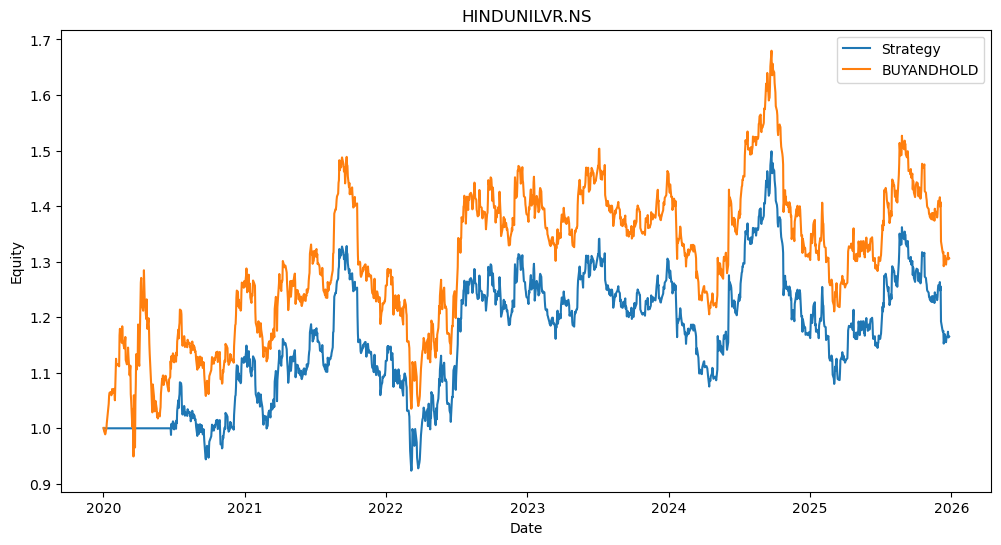

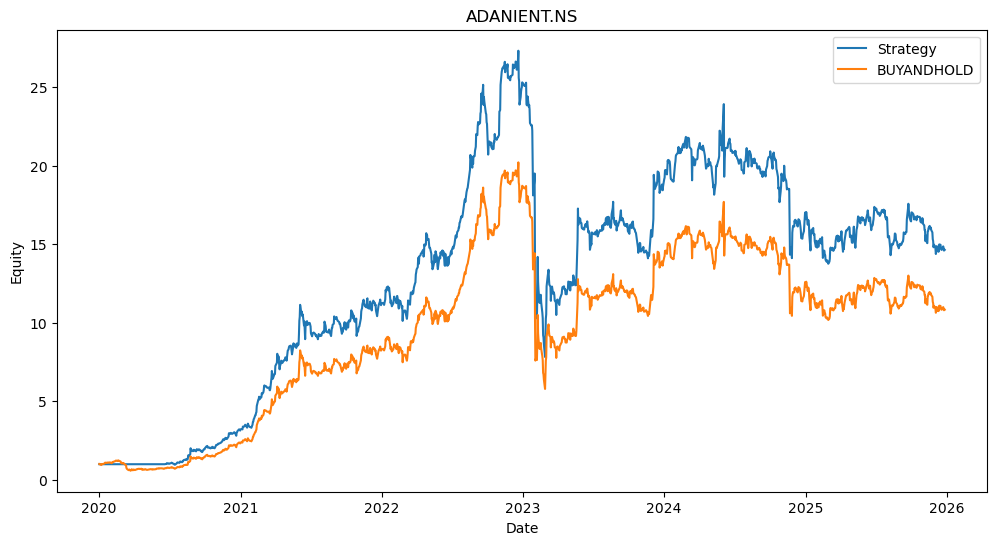

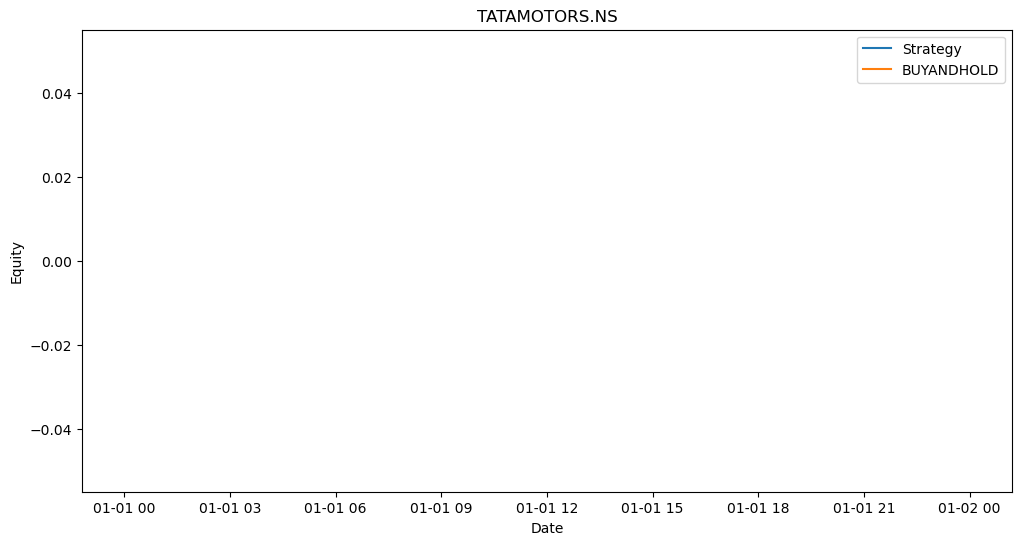

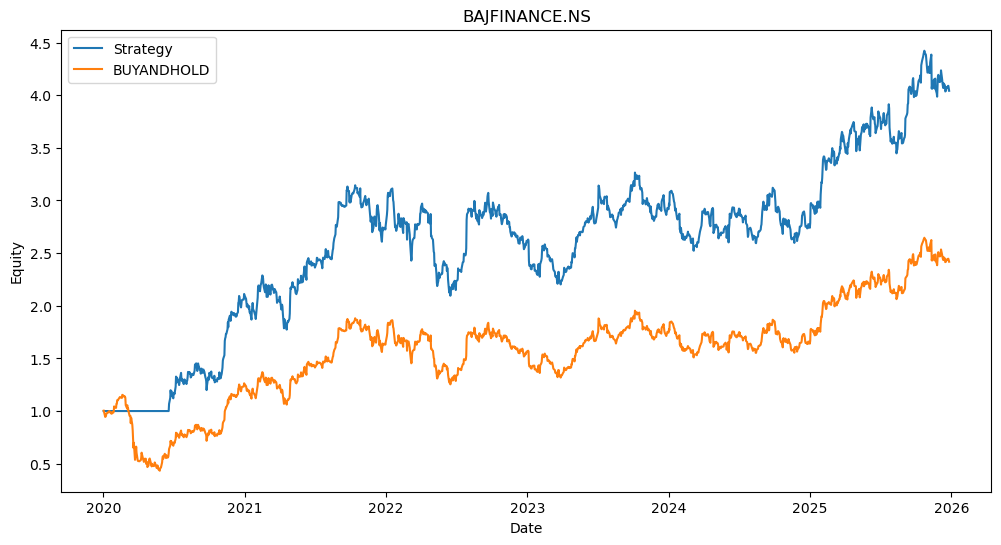

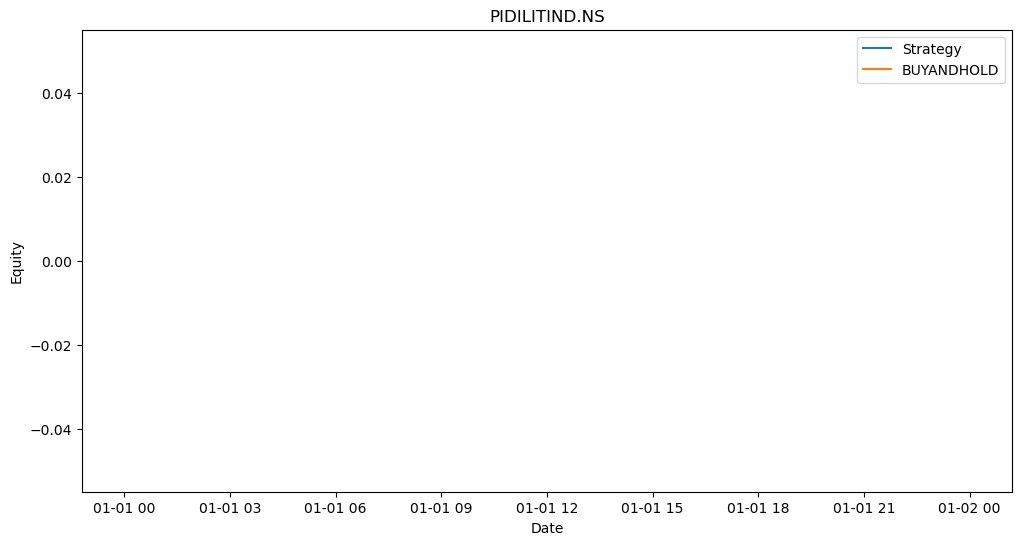

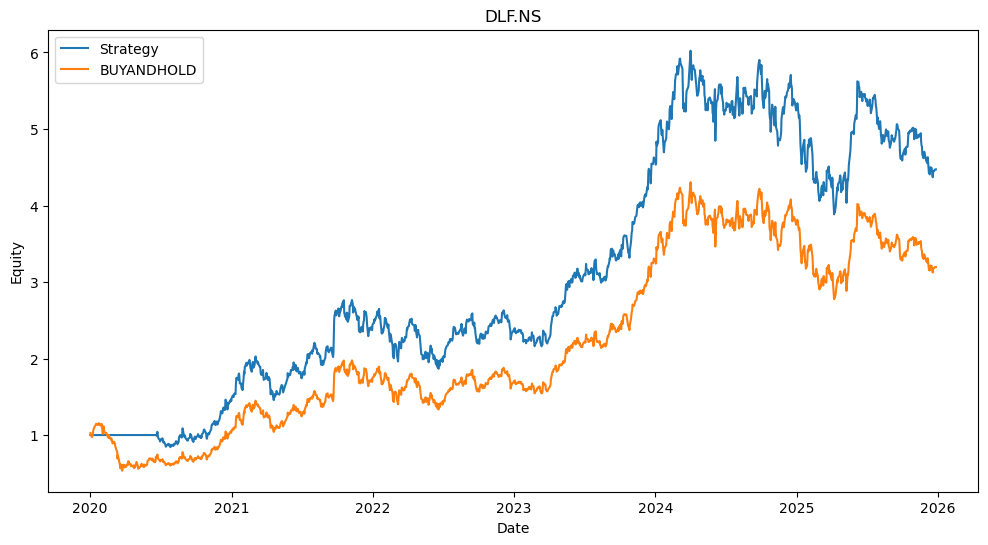

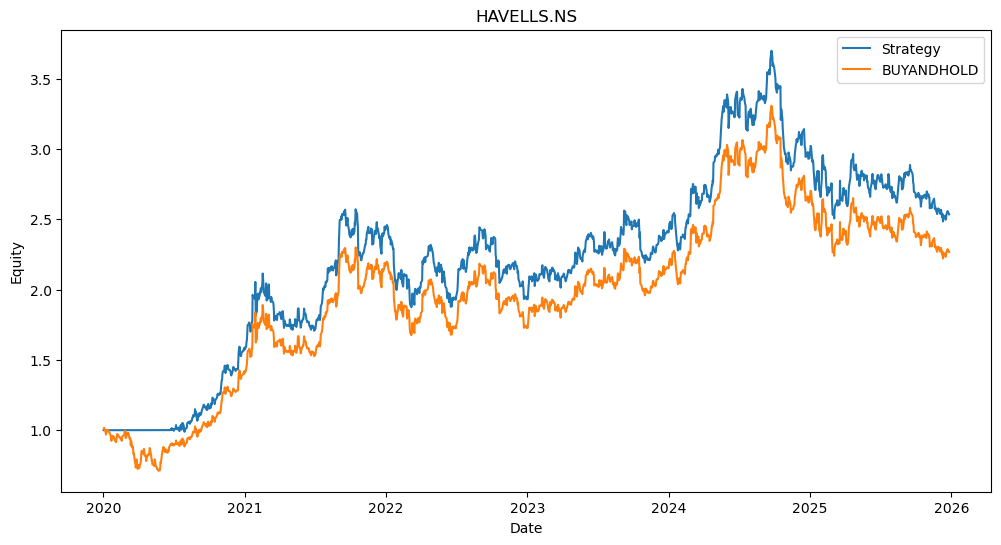

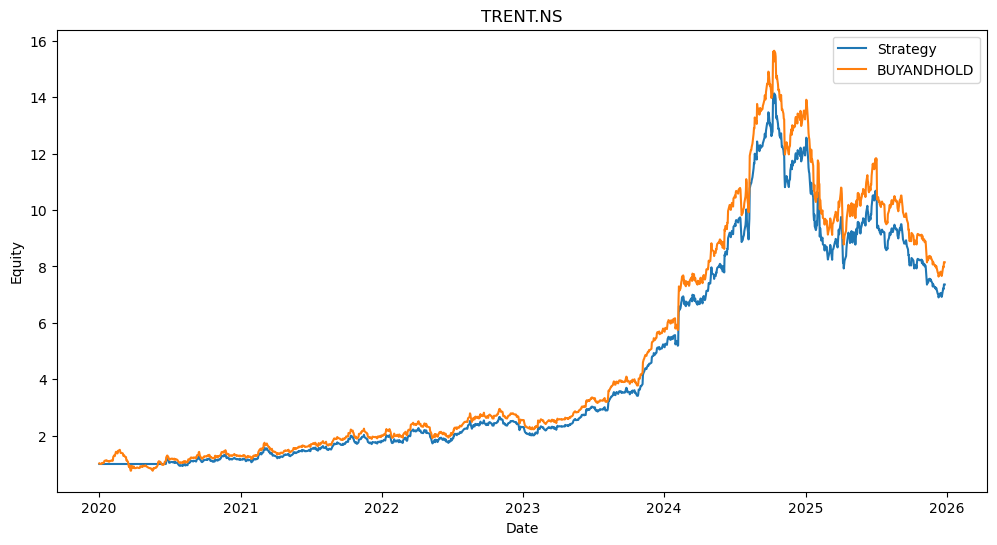

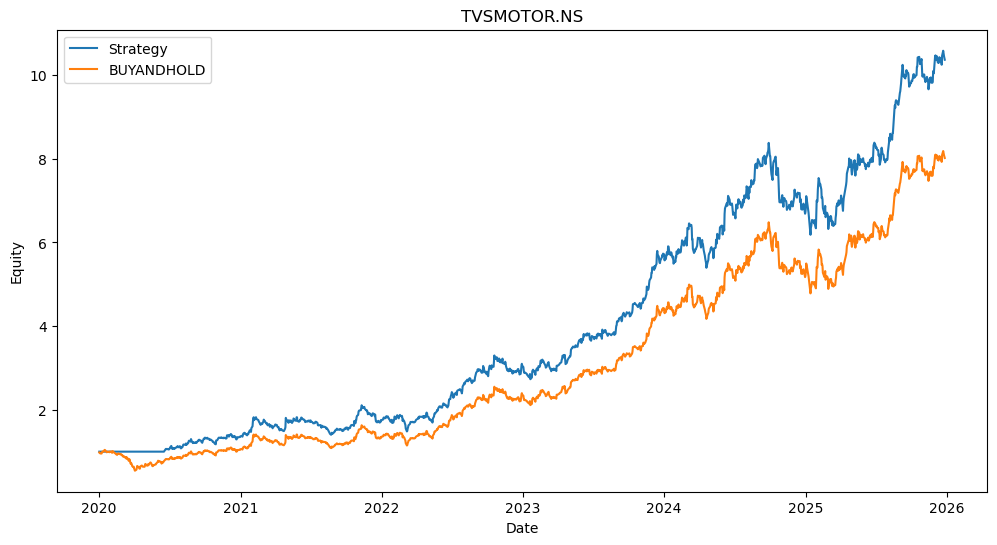

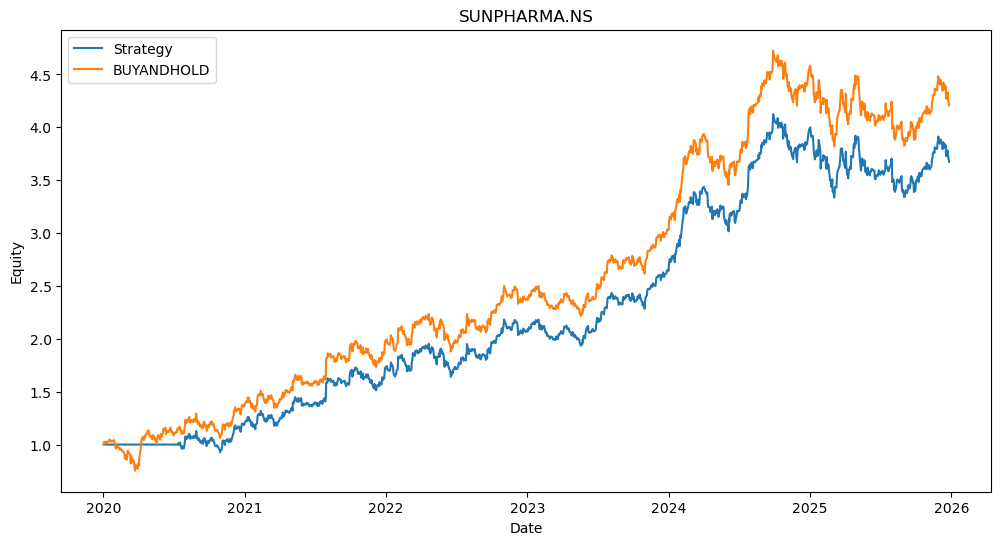

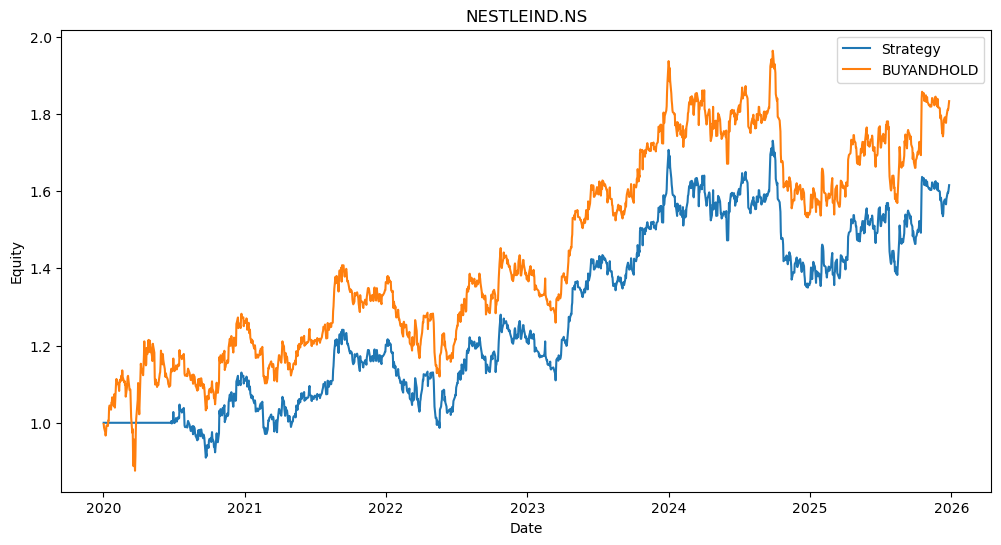

In [122]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


tickers = [
    "RELIANCE.NS",   # Reliance Industries
    "TCS.NS",        # Tata Consultancy Services
    "INFY.NS",       # Infosys
    "HDFCBANK.NS",   # HDFC Bank
    "ICICIBANK.NS",  # ICICI Bank
    "ITC.NS",        # ITC
    "LT.NS",         # Larsen & Toubro
    "SBIN.NS",       # State Bank of India
    "AXISBANK.NS",   # Axis Bank
    "HINDUNILVR.NS", # Hindustan Unilever
    "ADANIENT.NS",   # Adani Enterprises
    "TATAMOTORS.NS", # Tata Motors
    "BAJFINANCE.NS", # Bajaj Finance
    "PIDILITIND.NS", # Pidilite Industries
    "DLF.NS",        # DLF
    "HAVELLS.NS",    # Havells India
    "TRENT.NS",      # Trent
    "TVSMOTOR.NS",   # TVS Motor
    "SUNPHARMA.NS",  # Sun Pharma
    "NESTLEIND.NS"   # Nestle India
]



data={}
for ticker in tickers:
    df=yf.download(ticker, start="2020-01-01", multi_level_index=False)
    data[ticker]=df

DailyCapital=1_000_000

def run_strategy(ticker):
    df=data[ticker].copy()
    df["LowInWindow"]=df["Close"].rolling(window=10).min().shift(1)
    df["HighInWindow"]=df["Close"].rolling(window=10).max().shift(1)
    df["PriceIncrease"]=df["Close"].pct_change()
    df["Signal"]=0
    df["ClosePriceVolatility"]=df["PriceIncrease"].rolling(window=10).std().shift(1)
    df["VolFilter"]=df["ClosePriceVolatility"]<df["ClosePriceVolatility"].rolling(100).mean().shift(1)
    df.loc[((df["Close"]>df["HighInWindow"])&(df["VolFilter"]==1)), "Signal"]=1
    df.loc[((df["Close"]<df["LowInWindow"])), "Signal"]=0
    df["Position"]=df["Signal"].replace(0,np.nan).ffill().fillna(0)
    df["StrategyReturns"]=df["PriceIncrease"]*df["Position"].shift(1)
    df["BUYANDHOLDReturns"]=df["PriceIncrease"]
    df_clean=df.dropna()
    MeanReturnStrategy=df_clean["StrategyReturns"].mean()
    VolatilityStrategy=df_clean["StrategyReturns"].std()
    MeanReturnBUYANDHOLD=df_clean["BUYANDHOLDReturns"].mean()
    VolatilityBUYANDHOLD=df_clean["BUYANDHOLDReturns"].std()
    #print("____________________________________________")
    #print(f"Mean return by strategy is: {MeanReturnStrategy}")
    #print(f"Volatility of returns by strategy 1 is: {VolatilityStrategy}")
    #print(f"Sharpe Ratio: {np.sqrt(252)*MeanReturnStrategy/VolatilityStrategy}")
    #print("____________________________________________")
    #print(f"Mean return by BUYANDHOLD is: {MeanReturnBUYANDHOLD}")
    #print(f"Volatility of returns by BUYANDHOLD is: {VolatilityBUYANDHOLD}")
    #print(f"Sharpe Ratio: {np.sqrt(252)*MeanReturnBUYANDHOLD/VolatilityBUYANDHOLD}")
    #print("____________________________________________")
    #print(df)
    #print("____________________________________________")
    plt.style.use("default")
    df["StrategyEquity"]=(1+df["StrategyReturns"]).cumprod()
    df["BUYANDHOLDEquity"]=(1+df["BUYANDHOLDReturns"]).cumprod()
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df["StrategyEquity"], label="Strategy")
    plt.plot(df.index, df["BUYANDHOLDEquity"], label="BUYANDHOLD")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.title(ticker)
    plt.legend()
    #print(df_clean[["StrategyReturns", "BUYANDHOLDReturns"]].corr())
    
    MeanReturnStrategyRolling=df_clean["StrategyReturns"].rolling(window=5).mean()
    VolatilityStrategyRolling=df_clean["StrategyReturns"].rolling(window=5).std()
    MeanReturnBUYANDHOLDRolling=df_clean["BUYANDHOLDReturns"].rolling(window=5).mean()
    VolatilityBUYANDHOLDRolling=df_clean["BUYANDHOLDReturns"].rolling(window=5).std()
    mrs = MeanReturnStrategyRolling.dropna()
    mrb = MeanReturnBUYANDHOLDRolling.dropna()
    vs  = VolatilityStrategyRolling.dropna()
    vb  = VolatilityBUYANDHOLDRolling.dropna()
    
    if len(mrs) == 0 or len(mrb) == 0 or len(vs) == 0 or len(vb) == 0:
        return None, None, None, None
    
    return mrs.iloc[-1], mrb.iloc[-1], vs.iloc[-1], vb.iloc[-1]
allocations={}
for ticker in tickers:
    StratReturn, BAHReturn, StratVol, BAHVol=run_strategy(ticker)
    if StratReturn is None:
        allocations[ticker] = 0
        continue
    if (StratReturn>BAHReturn):
        if (StratReturn>0):
            allocations[ticker]=StratReturn/StratVol
        else:
            allocations[ticker]=0;
    else:
        allocations[ticker]=0
alloctotal=sum(allocations.values())
for ticker in tickers:
    if (alloctotal==0):
        allocations[ticker]=0
    else:
        allocations[ticker]=DailyCapital*allocations[ticker]/alloctotal
print(allocations)


capital_alloc=pd.DataFrame({"Ticker":list(allocations.keys()), "Allocated Capital":list(allocations.values())})
print(capital_alloc)
print(f"Total Capital Allocated: {capital_alloc['Allocated Capital'].sum()}")